## Import Libraries

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data

In [3]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

## Data Inspection & Transformation

In [4]:
print('X_test.shape: ', X_test.shape)
print('X_train.shape: ', X_train.shape)
print('y_test.shape: ', y_test.shape)
print('y_train.shape: ', y_train.shape)

X_test.shape:  (10000, 32, 32, 3)
X_train.shape:  (50000, 32, 32, 3)
y_test.shape:  (10000, 1)
y_train.shape:  (50000, 1)


In [9]:
X_test[:5]

array([[[[158, 112,  49],
         [159, 111,  47],
         [165, 116,  51],
         ...,
         [137,  95,  36],
         [126,  91,  36],
         [116,  85,  33]],

        [[152, 112,  51],
         [151, 110,  40],
         [159, 114,  45],
         ...,
         [136,  95,  31],
         [125,  91,  32],
         [119,  88,  34]],

        [[151, 110,  47],
         [151, 109,  33],
         [158, 111,  36],
         ...,
         [139,  98,  34],
         [130,  95,  34],
         [120,  89,  33]],

        ...,

        [[ 68, 124, 177],
         [ 42, 100, 148],
         [ 31,  88, 137],
         ...,
         [ 38,  97, 146],
         [ 13,  64, 108],
         [ 40,  85, 127]],

        [[ 61, 116, 168],
         [ 49, 102, 148],
         [ 35,  85, 132],
         ...,
         [ 26,  82, 130],
         [ 29,  82, 126],
         [ 20,  64, 107]],

        [[ 54, 107, 160],
         [ 56, 105, 149],
         [ 45,  89, 132],
         ...,
         [ 24,  77, 124],
        

In [4]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [5]:
# Convert 2D array to 1D array
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [6]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [7]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

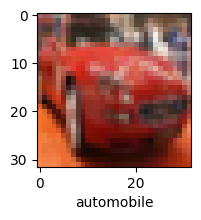

In [8]:
plot_sample(X_train, y_train, 5)

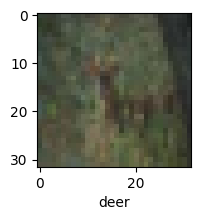

In [9]:
plot_sample(X_train, y_train, 10)

In [10]:
# Normalise to range between 0 to 1
X_train = X_train / 255.0
X_test = X_test / 255.0

## Model Training and Testing

### Artificial Neural Network (ANN)

In [11]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

history_ann = ann.fit(X_train, y_train, epochs=10)

c:\Users\yuyla\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.3532 - loss: 1.8173
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4271 - loss: 1.6251
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.4578 - loss: 1.5440
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.4790 - loss: 1.4833
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4959 - loss: 1.4347
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.5089 - loss: 1.3910
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.5261 - loss: 1.3526
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.5373 - loss: 1.3182
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - accuracy: 0.5509 - loss: 1.2843
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.5603 - loss: 1.2542


In [12]:
y_ann_pred = ann.predict(X_test)
y_ann_pred_classes = [np.argmax(element) for element in y_ann_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [13]:
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5171 - loss: 1.3580


[1.35795259475708, 0.5170999765396118]

In [14]:
# Classification report
print('Classification report for ANN: \n', classification_report(y_test, y_ann_pred_classes, target_names=classes))

Classification report for ANN: 
               precision    recall  f1-score   support

    airplane       0.48      0.71      0.57      1000
  automobile       0.60      0.69      0.65      1000
        bird       0.41      0.37      0.39      1000
         cat       0.41      0.30      0.35      1000
        deer       0.37      0.56      0.44      1000
         dog       0.54      0.33      0.40      1000
        frog       0.56      0.57      0.56      1000
       horse       0.68      0.48      0.56      1000
        ship       0.66      0.63      0.64      1000
       truck       0.58      0.53      0.55      1000

    accuracy                           0.52     10000
   macro avg       0.53      0.52      0.51     10000
weighted avg       0.53      0.52      0.51     10000



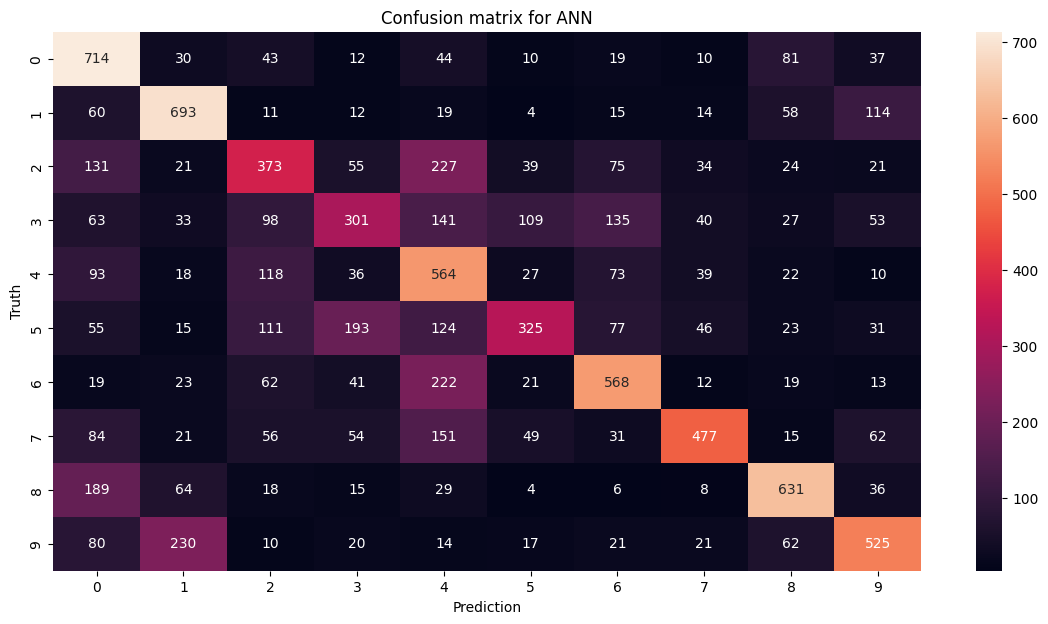

In [15]:
# Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(confusion_matrix(y_test, y_ann_pred_classes), annot=True, fmt='d')
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix for ANN')
plt.show()

### Convolutional Neural Network (CNN)

In [16]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', 
            loss = 'sparse_categorical_crossentropy', 
            metrics=['accuracy'])

history_cnn = cnn.fit(X_train, y_train, epochs=10)

c:\Users\yuyla\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4685 - loss: 1.4836
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6025 - loss: 1.1304
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6549 - loss: 0.9871
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.6852 - loss: 0.9038
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.7084 - loss: 0.8392
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7250 - loss: 0.7873
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7427 - loss: 0.7413
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7556 - loss: 0.6969
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7697 - loss: 0.6610
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7832 - loss: 0.6261


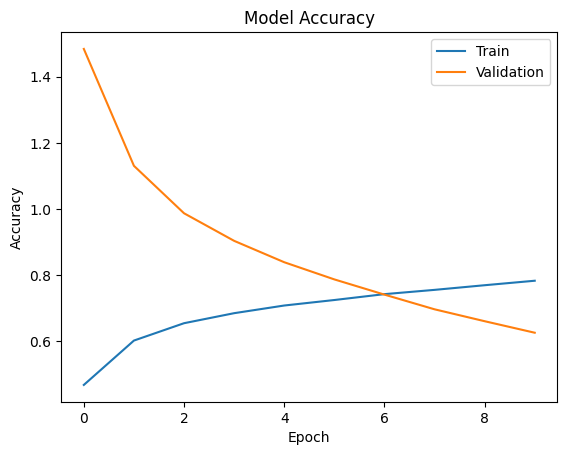

In [17]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['loss'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [18]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6836 - loss: 0.9603


[0.960335373878479, 0.6836000084877014]

In [19]:
y_cnn_pred = cnn.predict(X_test)
y_cnn_pred_classes = [np.argmax(element) for element in y_cnn_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [20]:
print('Classification report for CNN: \n', classification_report(y_test, y_cnn_pred_classes, target_names=classes))

Classification report for CNN: 
               precision    recall  f1-score   support

    airplane       0.72      0.74      0.73      1000
  automobile       0.88      0.74      0.81      1000
        bird       0.47      0.68      0.56      1000
         cat       0.51      0.52      0.51      1000
        deer       0.59      0.67      0.63      1000
         dog       0.72      0.43      0.54      1000
        frog       0.75      0.78      0.77      1000
       horse       0.85      0.64      0.73      1000
        ship       0.78      0.82      0.80      1000
       truck       0.74      0.81      0.77      1000

    accuracy                           0.68     10000
   macro avg       0.70      0.68      0.68     10000
weighted avg       0.70      0.68      0.68     10000



Prediction: deer


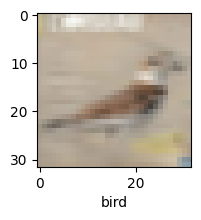

In [21]:
# Check test and predicted data
plot_sample(X_test, y_test, 70)
print('Prediction:', classes[y_cnn_pred_classes[70]])

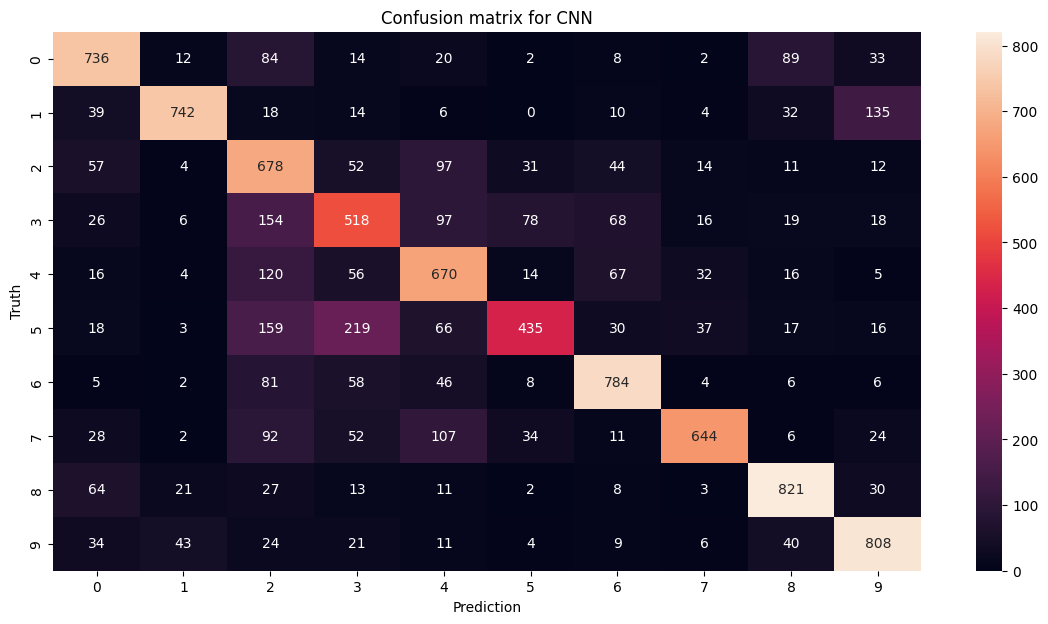

In [22]:
plt.figure(figsize=(14, 7))
sns.heatmap(confusion_matrix(y_test, y_cnn_pred_classes), annot=True, fmt='d')
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix for CNN')
plt.show()

### Improved CNN

In [23]:
# Create the model
improved_cnn = models.Sequential([

    # Data augmentation (helps generalization)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
improved_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )
]

# improved_cnn.fit(
#     X_train, y_train,
#     epochs=30,
#     validation_data=(X_test, y_test),
#     callbacks=callbacks
# )

history_improved = improved_cnn.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=callbacks
)

c:\Users\yuyla\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 71s 53ms/step - accuracy: 0.3769 - loss: 1.8040 - val_accuracy: 0.4040 - val_loss: 1.8904 - learning_rate: 0.0010
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 54ms/step - accuracy: 0.5031 - loss: 1.3913 - val_accuracy: 0.5096 - val_loss: 1.5130 - learning_rate: 0.0010
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.5470 - loss: 1.2773 - val_accuracy: 0.5811 - val_loss: 1.2106 - learning_rate: 0.0010
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 53ms/step - accuracy: 0.5824 - loss: 1.1822 - val_accuracy: 0.5700 - val_loss: 1.2684 - learning_rate: 0.0010
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.6087 - loss: 1.1077 - val_accuracy: 0.6539 - val_loss: 1.0060 - learning_rate: 0.0010
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 67s 54ms/step - accuracy: 0.6264 - loss: 1.0607 - val_accuracy: 0.6672 - val_loss: 1.0728 - learning_rate: 0.0010
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 55ms/step - accura

In [24]:
improved_cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7980 - loss: 0.5946


[0.5946051478385925, 0.7979999780654907]

In [25]:
y_improved_cnn_pred = improved_cnn.predict(X_test)
y_improved_cnn_pred_classes = [np.argmax(element) for element in y_improved_cnn_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


In [26]:
print('Classification report for Improved CNN: \n', classification_report(y_test, y_improved_cnn_pred_classes, target_names=classes))

Classification report for Improved CNN: 
               precision    recall  f1-score   support

    airplane       0.82      0.82      0.82      1000
  automobile       0.90      0.93      0.91      1000
        bird       0.80      0.69      0.74      1000
         cat       0.75      0.52      0.62      1000
        deer       0.78      0.75      0.76      1000
         dog       0.85      0.62      0.72      1000
        frog       0.68      0.93      0.78      1000
       horse       0.79      0.89      0.84      1000
        ship       0.83      0.93      0.88      1000
       truck       0.83      0.90      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000



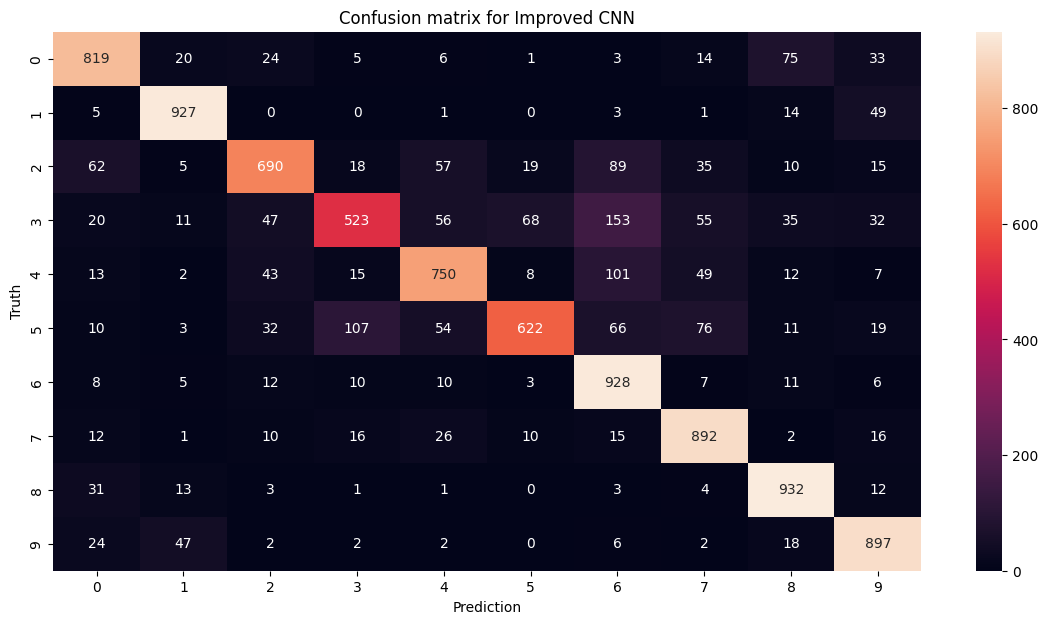

In [27]:
plt.figure(figsize=(14, 7))
sns.heatmap(confusion_matrix(y_test, y_improved_cnn_pred_classes), annot=True, fmt='d')
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix for Improved CNN')
plt.show()

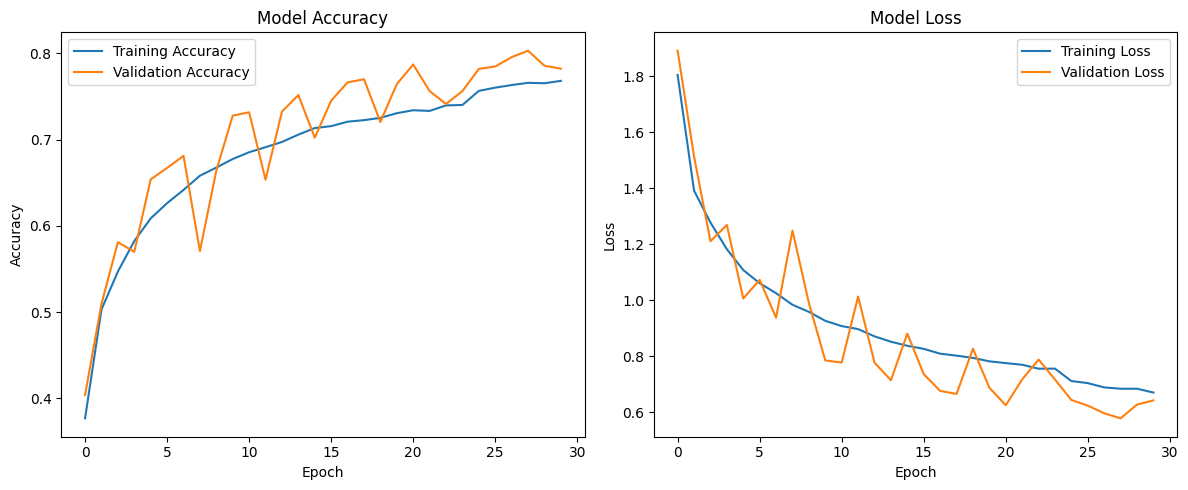

In [28]:
# Accuracy Graph
# Shows how accuracy changes during training.
    # Training accuracy = performance on training data
    # Validation accuracy = performance on unseen test/validation data
# Good sign:
    # both increase steadily
    # validation accuracy close to training accuracy
# Possible overfitting:
    # training accuracy keeps increasing
    # validation accuracy stops improving or decreases

# Loss Graph
# Shows prediction error during training.
# Good sign:
    # both losses decrease steadily
# Possible overfitting:
    # training loss decreases
    # validation loss increases

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Improved CNN without validation

In [ ]:
# Create the model
improved_cnn2 = models.Sequential([

    # Data augmentation (helps generalization)
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile the model
improved_cnn2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True
    )
]

# improved_cnn.fit(
#     X_train, y_train,
#     epochs=30,
#     validation_data=(X_test, y_test),
#     callbacks=callbacks
# )

history_improved = improved_cnn2.fit(
    X_train, y_train,
    epochs=30,
    # validation_split=0.2,
    # callbacks=callbacks
)

c:\Users\yuyla\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 54ms/step - accuracy: 0.3938 - loss: 1.7553
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.5186 - loss: 1.3480
Epoch 3/30
  52/1563 ━━━━━━━━━━━━━━━━━━━━ 1:17 51ms/step - accuracy: 0.5535 - loss: 1.2390

In [ ]:
improved_cnn2.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7805 - loss: 0.6287


[0.6287064552307129, 0.7804999947547913]

In [ ]:
y_improved_cnn2_pred = improved_cnn2.predict(X_test)
y_improved_cnn2_pred_classes = [np.argmax(element) for element in y_improved_cnn2_pred]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


In [ ]:
print('Classification report for Improved CNN: \n', classification_report(y_test, y_improved_cnn2_pred_classes, target_names=classes))

Classification report for Improved CNN: 
               precision    recall  f1-score   support

    airplane       0.86      0.77      0.81      1000
  automobile       0.94      0.85      0.89      1000
        bird       0.79      0.68      0.73      1000
         cat       0.60      0.70      0.65      1000
        deer       0.82      0.67      0.73      1000
         dog       0.83      0.61      0.70      1000
        frog       0.61      0.95      0.74      1000
       horse       0.92      0.75      0.83      1000
        ship       0.80      0.94      0.86      1000
       truck       0.84      0.90      0.87      1000

    accuracy                           0.78     10000
   macro avg       0.80      0.78      0.78     10000
weighted avg       0.80      0.78      0.78     10000



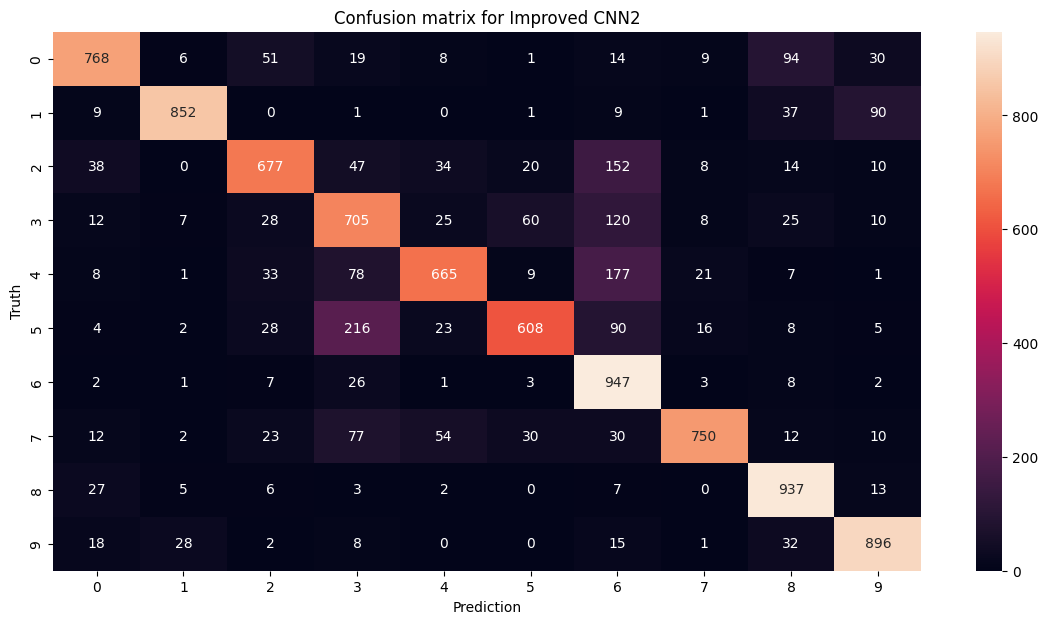

In [ ]:
plt.figure(figsize=(14, 7))
sns.heatmap(confusion_matrix(y_test, y_improved_cnn2_pred_classes), annot=True, fmt='d')
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion matrix for Improved CNN2')
plt.show()

In [ ]:
ann.summary()
cnn.summary()
improved_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3000)           │     9,219,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │     3,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,230,012 (46.65 MB)

 Trainable params: 12,230,010 (46.65 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,003,456 (7.64 MB)

 Trainable params: 667,498 (2.55 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,334,998 (5.09 MB)